#Multiple Linear Regression - Toyota Corolla Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [6]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


#Statistical Summary
Describe() provides
- Mean
- Median (50%)
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#Removing Duplicate Rows

Duplicate rows can affect the performance of a machine learning model by giving repeated importance to the same observations.

The `drop_duplicates()` function is used to remove duplicate records from the dataset. After removing duplicates, the dataset is checked again to ensure that no duplicate rows remain.

#Identifying Numerical and Categorical Columns

Before performing Exploratory Data Analysis (EDA), it is important to identify which columns are numerical and which are categorical.

- Numerical columns are used for statistical analysis and visualizations such as histograms and box plots.
- Categorical columns are used for count plots and encoding before model building.

In [9]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')

Categorical Columns:
Index(['Fuel_Type'], dtype='object')


#Histogram

A histogram is used to understand the distribution of numerical variables.

It helps identify:
- Data distribution
- Skewness
- Frequency of values

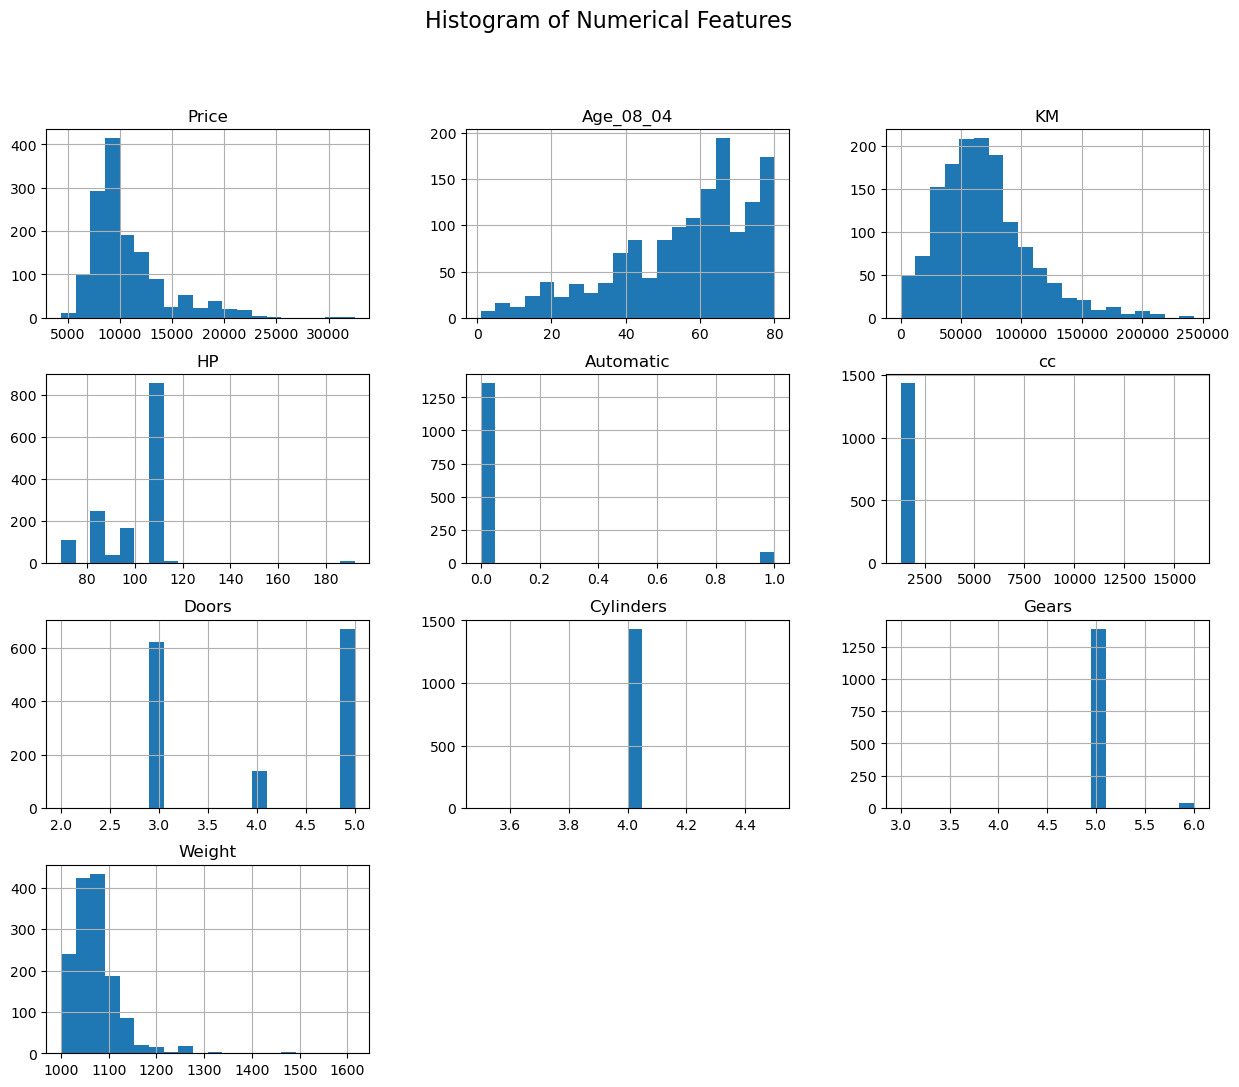

In [10]:
df[num_cols].hist(figsize=(15,12), bins=20)

plt.suptitle("Histogram of Numerical Features", fontsize=16)

plt.show()

#Box Plot

A box plot is used to visualize the spread of numerical data and identify outliers.

It helps us:
- Detect outliers
- Find the median
- Understand the spread of data
- Compare distributions of different numerical variables

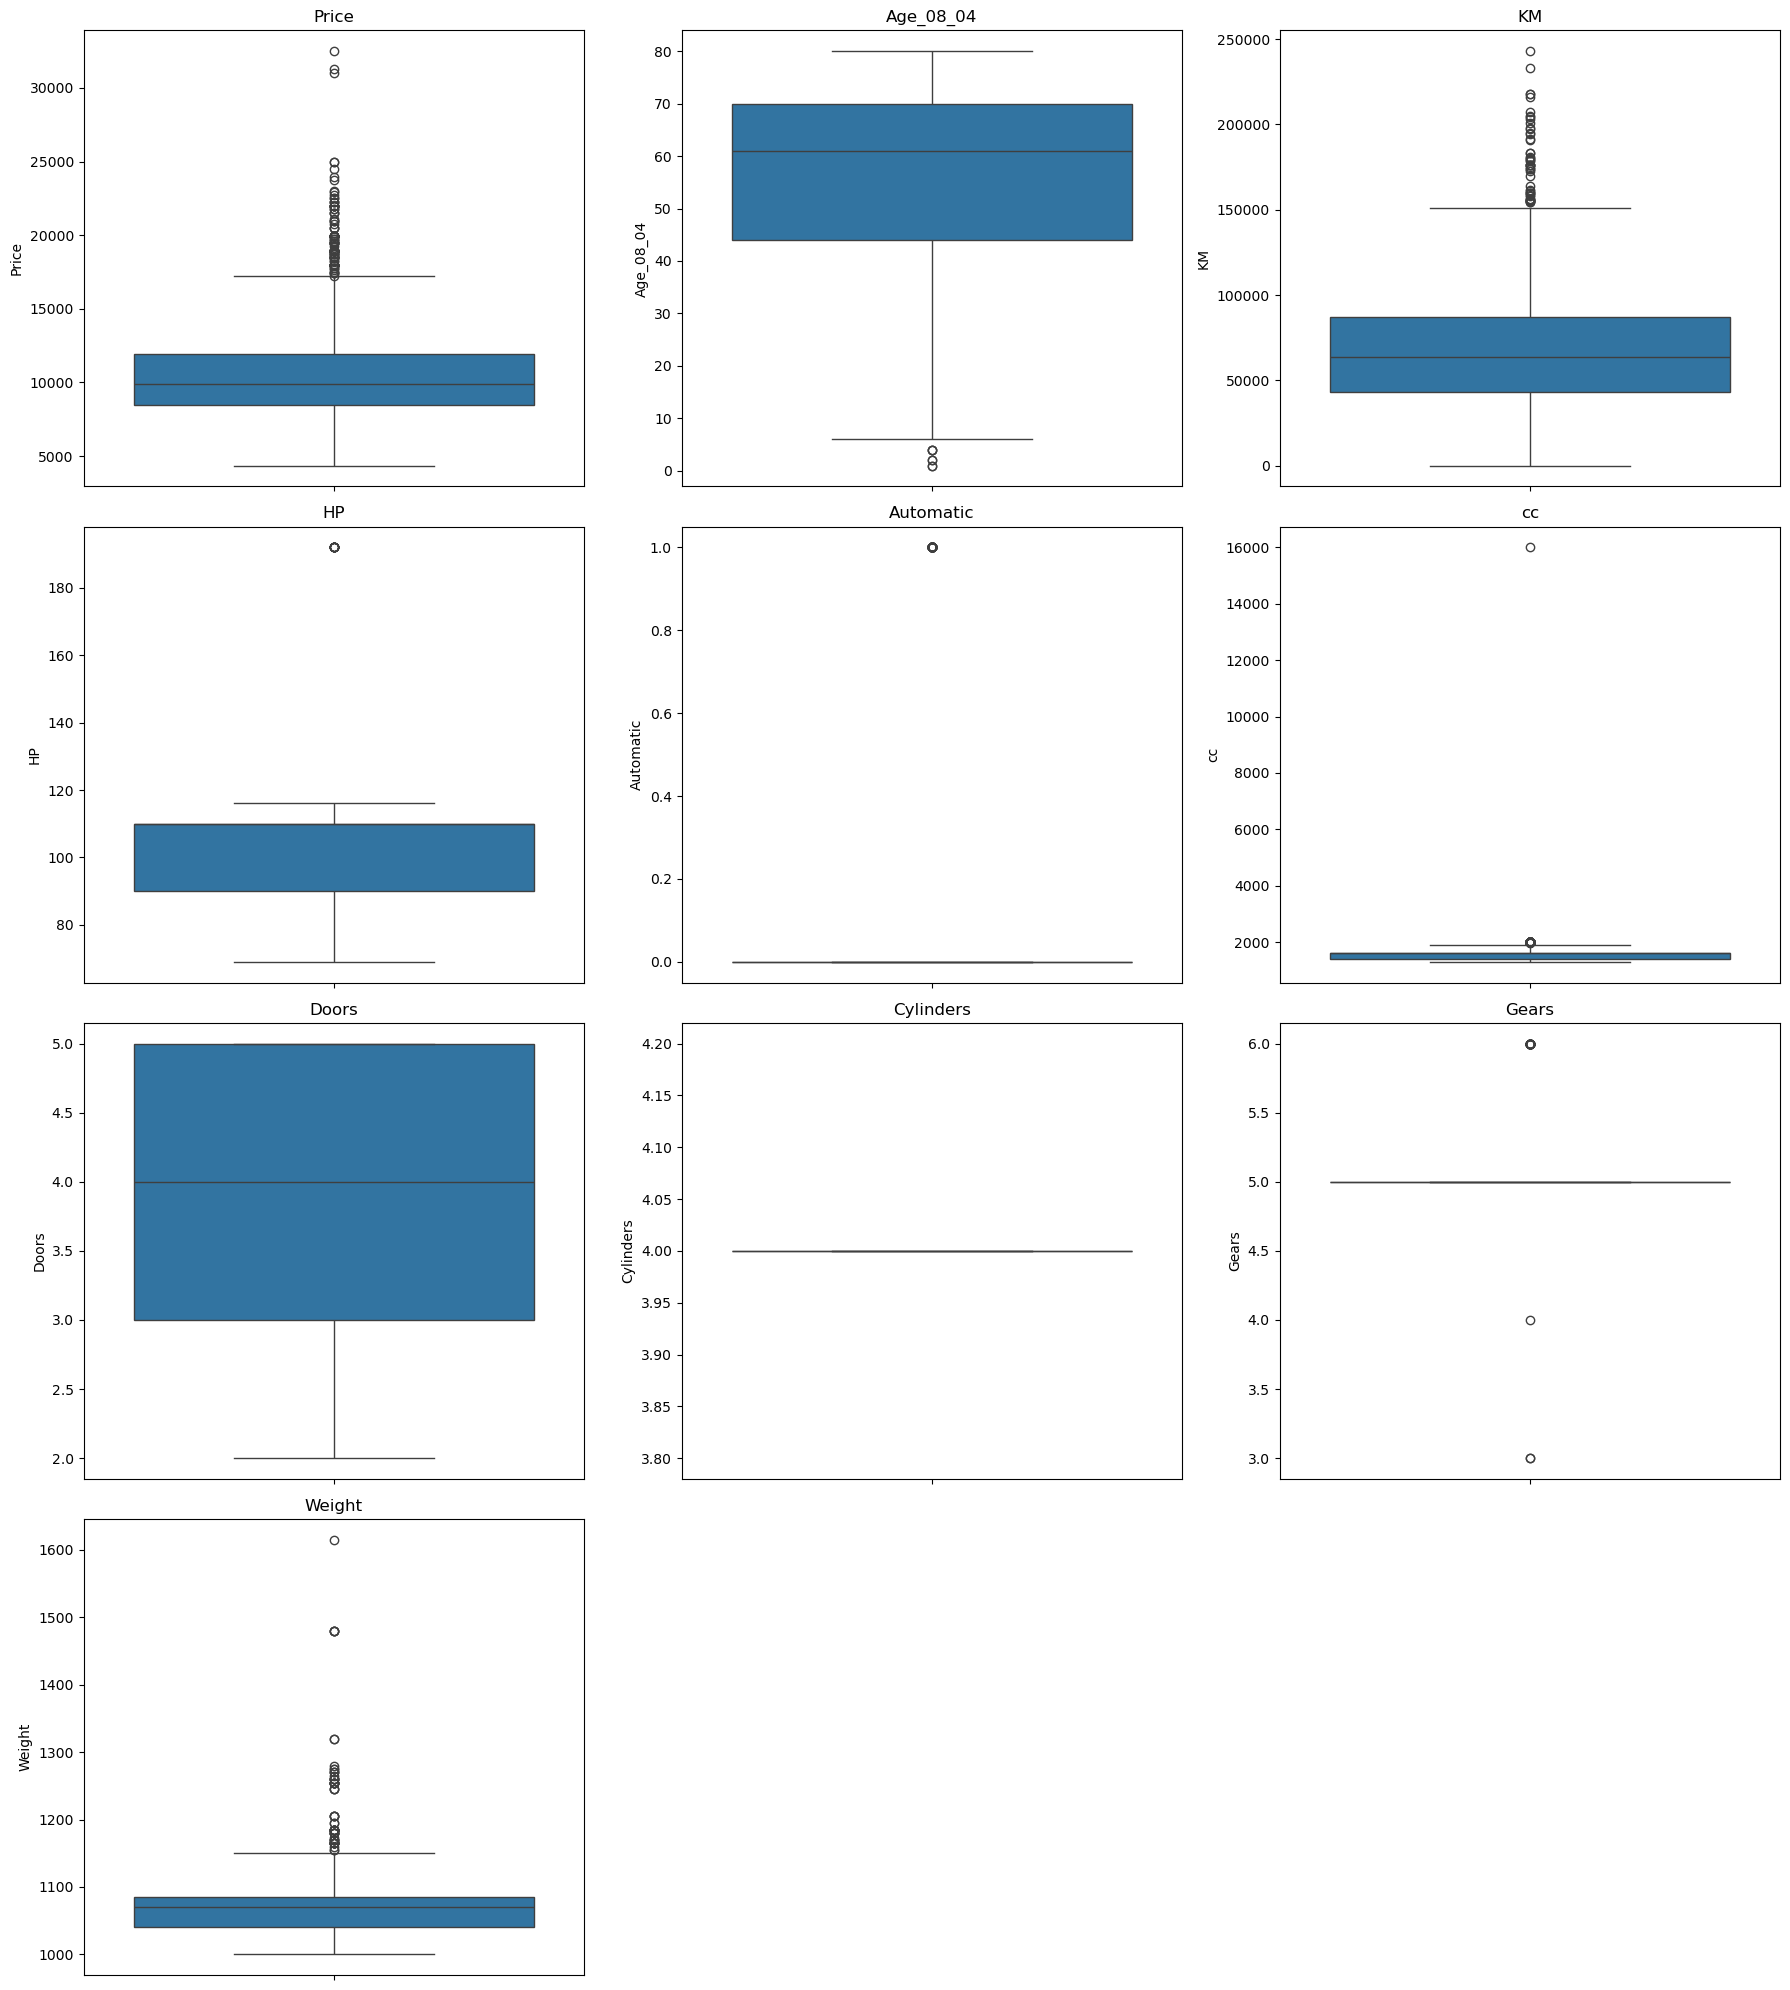

In [11]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate number of rows required
rows = (len(num_cols) + 2) // 3

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(num_cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#Correlation Heatmap

A correlation heatmap is used to measure the relationship between numerical variables.

Correlation values range from:

- +1 : Strong positive relationship
- 0 : No relationship
- -1 : Strong negative relationship

In [12]:
df.nunique()

Price         236
Age_08_04      77
KM           1263
Fuel_Type       3
HP             12
Automatic       2
cc             13
Doors           4
Cylinders       1
Gears           4
Weight         59
dtype: int64

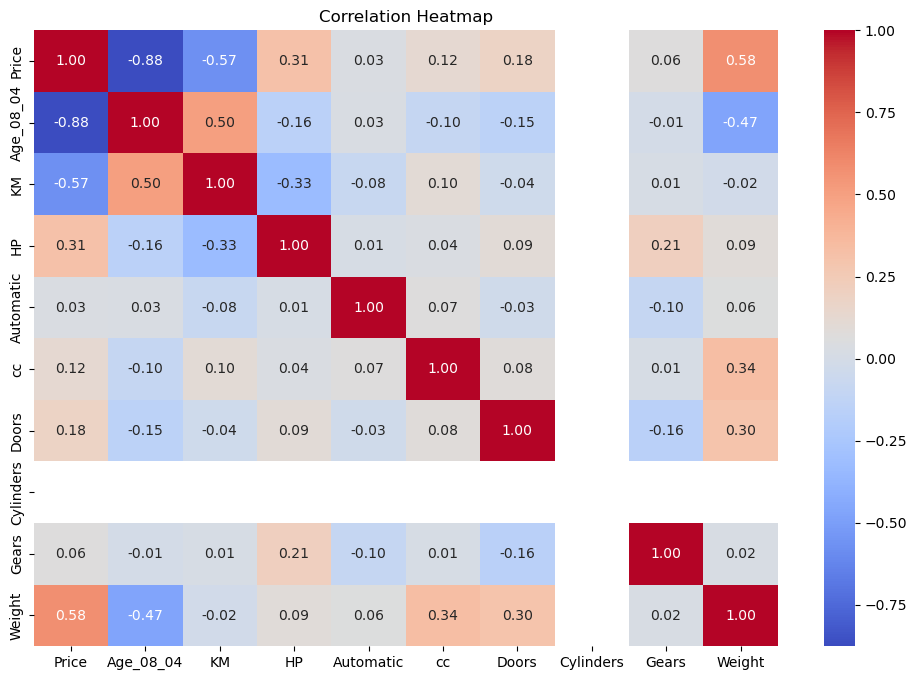

In [13]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

#Observation

The `Cylinders` column contains only one unique value for all observations. Since it has no variation, its correlation with other variables cannot be computed, resulting in blank cells in the correlation heatmap. Therefore, this feature does not contribute to the prediction model and can be removed during preprocessing.


#Observation

- Price has a strong negative correlation with Age (-0.88). This indicates that older cars tend to have lower prices.
- Price has a moderate negative correlation with KM (-0.57). Cars with higher mileage generally have lower prices.
- Price has a moderate positive correlation with Weight (0.58). Heavier cars tend to have higher prices.
- HP (Horse Power) has a weak positive correlation (0.31) with Price.
- Automatic, CC, Doors, and Gears have weak correlations with Price.
- There is no evidence of extremely high correlation (greater than 0.9) among most independent variables, although VIF analysis can be used later to confirm multicollinearity.

#Encoding Categorical Variables

Machine learning models cannot directly process text values.

The FuelType column contains categorical values (Petrol, Diesel, CNG), so it is converted into numerical values using One-Hot Encoding.

In [14]:
# Convert categorical column into numerical columns
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

# Display first five rows
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


#Define Features and Target Variable

The independent variables are stored in X, and the dependent variable (Price) is stored in y.

In [15]:
# Features (Independent Variables)
X = df.drop('Price', axis=1)

# Target Variable
y = df['Price']


#Train-Test Split

The dataset is divided into training and testing sets.

- 80% Training Data
- 20% Testing Data

The model learns from the training data and is evaluated on the testing data.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



#Model 1: Multiple Linear Regression

In this step, we build the first Multiple Linear Regression model using all the independent variables.

The model learns the relationship between the predictor variables and the target variable (Price).

In [17]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
model1 = LinearRegression()

# Train the model
model1.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


#Model Coefficients

The coefficients indicate how each independent variable affects the target variable (Price).

- Positive coefficient → Price increases.
- Negative coefficient → Price decreases.

In [18]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})

coef

,Feature,Coefficient
0,Age_08_04,-1.212292e+02
1,KM,-1.599715e-02
2,HP,1.607544e+01
3,Automatic,2.688222e+02
4,cc,-4.710949e-02
5,Doors,-8.809716e+01
6,Cylinders,-8.526513e-14
7,Gears,4.550119e+02
8,Weight,2.636120e+01
9,Fuel_Type_Diesel,-3.896838e+02


#Prediction

After training, the model predicts the prices of cars in the test dataset.

In [19]:
# Predict test data
y_pred = model1.predict(X_test)

# Display first 10 predictions
prediction = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

prediction.head(10)

,Actual Price,Predicted Price
753,9950,10807.905356
858,7995,10326.707030
630,7500,9168.774419
1412,9950,9347.156265
975,8950,8470.341325
800,8995,8543.655424
1030,9450,7890.514913
1372,6750,8267.185158
260,11950,11740.098252
317,10950,12334.336739


#Model Evaluation

The performance of the Multiple Linear Regression model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [21]:
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 986.4966877482503
Mean Squared Error (MSE): 2155628.3561396245
Root Mean Squared Error (RMSE): 1468.2058289421223
R² Score: 0.8203213869961807


#Actual vs Predicted Values

This scatter plot compares the actual car prices with the prices predicted by the model.

If the model performs well, the points should lie close to the diagonal line.

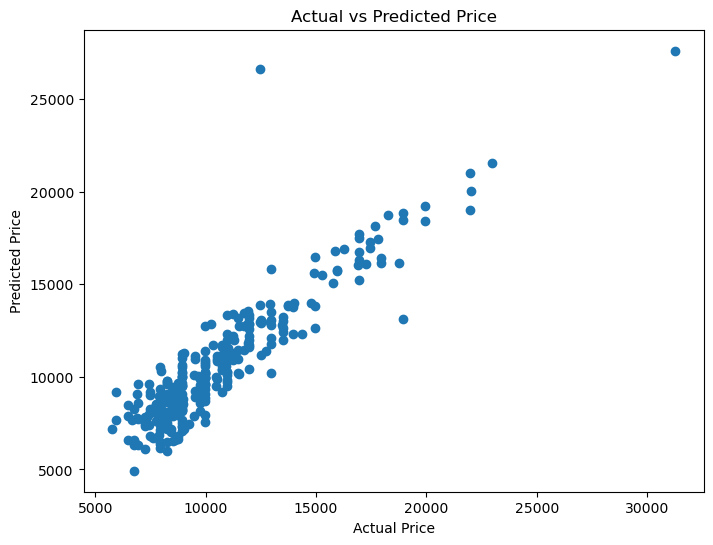

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

#Model 2: Multiple Linear Regression using Selected Features

In this model, only the important features are selected to predict the price of Toyota Corolla cars.

Selected Features:
- Age_08_04
- KM
- HP
- Automatic
- CC
- Gears
- Weight

The features 'Doors' and 'Cylinders' are excluded because they have a weak influence on the target variable and do not significantly improve the model performance.

In [23]:
# Independent Variables
X2 = df[['Age_08_04',
         'KM',
         'HP',
         'Automatic',
         'cc',
         'Gears',
         'Weight']]

# Dependent Variable
y2 = df['Price']

Explanation:
X2 contains the selected independent variables.
y2 contains the target variable (Price).

In [24]:
# Split the dataset
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [25]:
# Create the Linear Regression model
model2 = LinearRegression()

# Train the model
model2.fit(X_train2, y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Explanation:
LinearRegression() creates the regression model.
fit() trains the model using the training dataset.

In [26]:
# Predict the prices
y_pred2 = model2.predict(X_test2)

In [27]:
prediction2 = pd.DataFrame({
    'Actual Price': y_test2,
    'Predicted Price': y_pred2
})

prediction2.head(10)

,Actual Price,Predicted Price
753,9950,10658.145946
858,7995,10337.635576
630,7500,9403.401485
1412,9950,9418.520590
975,8950,8430.747056
800,8995,8358.973123
1030,9450,8093.908114
1372,6750,8284.767431
260,11950,11778.233230
317,10950,12424.783490


In [28]:
# Calculate evaluation metrics
mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_test2, y_pred2)

print("Mean Absolute Error (MAE):", mae2)
print("Mean Squared Error (MSE):", mse2)
print("Root Mean Squared Error (RMSE):", rmse2)
print("R2 Score:", r22)

Mean Absolute Error (MAE): 989.2686531840878
Mean Squared Error (MSE): 1922866.757073698
Root Mean Squared Error (RMSE): 1386.6747120625291
R2 Score: 0.8397228209964337


In [29]:
coef2 = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model2.coef_
})

coef2

,Feature,Coefficient
0,Age_08_04,-121.551337
1,KM,-0.019560
2,HP,30.640105
3,Automatic,519.754741
4,cc,-0.139091
5,Gears,461.040428
6,Weight,19.940527


Explanation:

-The coefficients show how each feature affects the car price:
-Positive coefficient → As the feature increases, the price tends to increase.
-Negative coefficient → As the feature increases, the price tends to decrease.

#Model 3: Multiple Linear Regression using Top Features

In this model, only the most important features are selected.

Selected Features:
- Age_08_04
- KM
- HP
- Weight

The objective is to determine whether a simpler model with fewer features can achieve good prediction accuracy.

In [30]:
# Independent Variables
X3 = df[['Age_08_04',
         'KM',
         'HP',
         'Weight']]

# Dependent Variable
y3 = df['Price']

In [31]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42
)

In [32]:
# Create model
model3 = LinearRegression()

# Train model
model3.fit(X_train3, y_train3)
# Predict Price
y_pred3 = model3.predict(X_test3)

In [33]:
prediction3 = pd.DataFrame({
    "Actual Price": y_test3,
    "Predicted Price": y_pred3
})

prediction3.head(10)

,Actual Price,Predicted Price
753,9950,10243.695766
858,7995,10394.129812
630,7500,9441.818838
1412,9950,9495.156261
975,8950,8442.876090
800,8995,8355.895304
1030,9450,8118.809759
1372,6750,8360.497662
260,11950,11787.770820
317,10950,12438.929380


In [34]:
mae3 = mean_absolute_error(y_test3, y_pred3)

mse3 = mean_squared_error(y_test3, y_pred3)

rmse3 = np.sqrt(mse3)

r23 = r2_score(y_test3, y_pred3)

print("Mean Absolute Error (MAE):", mae3)
print("Mean Squared Error (MSE):", mse3)
print("Root Mean Squared Error (RMSE):", rmse3)
print("R2 Score:", r23)

Mean Absolute Error (MAE): 987.225283393743
Mean Squared Error (MSE): 1934478.819382428
Root Mean Squared Error (RMSE): 1390.8554272038587
R2 Score: 0.8387549179514566


In [35]:
coef3 = pd.DataFrame({
    "Feature": X3.columns,
    "Coefficient": model3.coef_
})

coef3

,Feature,Coefficient
0,Age_08_04,-120.619071
1,KM,-0.020074
2,HP,31.478589
3,Weight,19.847999


#Model Comparison

The performance of all three Multiple Linear Regression models is compared using MAE, MSE, RMSE, and R² Score.

In [36]:
comparison = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "MAE": [mae, mae2, mae3],
    "MSE": [mse, mse2, mse3],
    "RMSE": [rmse, rmse2, rmse3],
    "R2 Score": [r2, r22, r23]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Model 1,986.496688,2.155628e+06,1468.205829,0.820321
1,Model 2,989.268653,1.922867e+06,1386.674712,0.839723
2,Model 3,987.225283,1.934479e+06,1390.855427,0.838755


Interpretation:
-Compare the R² Score of all three models.
-The model with the highest R² Score and the lowest MAE, MSE, and RMSE is considered the best.

#Ridge Regression

Ridge Regression is a regularization technique used to reduce overfitting and handle multicollinearity.

It adds an L2 penalty to the cost function, which shrinks the coefficient values without making them exactly zero.

In [37]:
from sklearn.linear_model import Ridge

# Create Ridge model
ridge = Ridge(alpha=1.0)

# Train the model
ridge.fit(X_train, y_train)

# Predict
ridge_pred = ridge.predict(X_test)



#Ridge Regression Evaluation

The Ridge Regression model is evaluated using MAE, MSE, RMSE, and R² Score.

In [38]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2 Score :", ridge_r2)

MAE : 986.8926016613875
MSE : 2152506.133638224
RMSE : 1467.1421654489466
R2 Score : 0.8205816343653263


Explanation

These metrics tell us how well the Ridge model performs.

A higher R² Score and lower error values indicate better performance.

#Lasso Regression

Lasso Regression is another regularization technique.

It applies L1 regularization, which can reduce some coefficients to exactly zero, automatically selecting the most important features.

In [40]:
from sklearn.linear_model import Lasso

# Create Lasso model
lasso = Lasso(alpha=1.0)

# Train the model
lasso.fit(X_train, y_train)

# Predict
lasso_pred = lasso.predict(X_test)

#Lasso Regression Evaluation

The Lasso Regression model is evaluated using MAE, MSE, RMSE, and R² Score.

In [41]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, lasso_pred)

print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R2 Score :", lasso_r2)

MAE : 985.7550486621649
MSE : 2146910.232520587
RMSE : 1465.2338490905083
R2 Score : 0.8210480708679172


#Comparison of All Models

The performance of Multiple Linear Regression, Ridge Regression, and Lasso Regression is compared using evaluation metrics.

In [42]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]
print(best_model)

Model              Model 2
MAE             989.268653
MSE         1922866.757074
RMSE           1386.674712
R2 Score          0.839723
Name: 1, dtype: object


#Conclusion

In this project, Multiple Linear Regression was used to predict the price of Toyota Corolla cars.

Three different Multiple Linear Regression models were built using different combinations of features. Their performance was evaluated using MAE, MSE, RMSE, and R² Score.

Ridge Regression and Lasso Regression were also applied to reduce overfitting and handle multicollinearity.

Among all the models, the one with the highest R² Score and the lowest error metrics was selected as the best-performing model for predicting car prices.

Interview Questions:
1.What is Normalization & Standardization and how is it helpful?
2.What techniques can be used to address multicollinearity in multiple linear regression?
Answer:
1)Normalization scales data to a fixed range, usually 0 to 1, while Standardization transforms data to have a mean of 0 and standard deviation of 1. Both techniques help improve model performance, ensure fair comparison among features, and speed up the training process.
________________________________________________________________________________________________
2)Multicollinearity occurs when independent variables are highly correlated, making the regression coefficients unstable. To address it, I first check the correlation matrix and VIF values. If multicollinearity exists, I remove highly correlated features or features with high VIF. I can also use feature selection techniques or apply Ridge Regression (L2 Regularization), which is specifically designed to handle multicollinearity.